## Настройка окружения

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Загрузка и первичный анализ данных с сбросом лишних столбцов

In [2]:
df = pd.read_csv('bank.csv')

print(f"Размер датасета: {df.shape[0]} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()

# В отличие от Churn_Modelling здесь нет ID/имён клиентов, зато есть duration —
# длительность последнего звонка. Она сильно коррелирует с результатом (кто долго
# говорит с оператором, чаще соглашается), НО на момент звонка мы её ещё не знаем,
# поэтому для честного прогноза "до звонка" этот признак нужно убрать (data leakage)
df = df.drop(['duration'], axis=1)

economic_stats = df.groupby('job')[['balance', 'campaign']].mean().round(1)
print('\nСредний баланс и число контактов по типу занятости\n', economic_stats)

print('\nПервые 3 строки данных')
df.head(3)

Размер датасета: 11162 клиентов и 17 признаков
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,-1,0,unknown,yes


## Визуализация данных через график

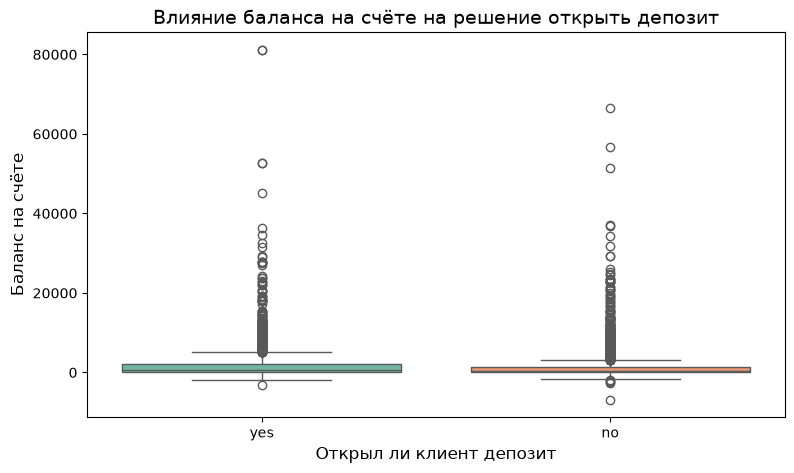

In [3]:
plt.figure(figsize=(9,5))

sns.boxplot(x="deposit", y="balance", data=df, palette="Set2", legend=False, hue="deposit")

plt.title("Влияние баланса на счёте на решение открыть депозит", fontsize=14)
plt.xlabel("Открыл ли клиент депозит", fontsize=12)
plt.ylabel("Баланс на счёте", fontsize=12)
plt.show()

## Подготовка признаков для обучения

In [4]:
y = df["deposit"].map({"no": 0, "yes": 1})
X = pd.get_dummies(
    df.drop("deposit", axis=1),
    columns=["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"],
    drop_first=True
)

print("Данные после обработки категориальных признаков")
X.head(3)

Данные после обработки категориальных признаков


,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## Масштабирование и разбиение данных для обучения

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

numeric_cols = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.head(3)

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
8644,0.412051,-0.321431,1.817208,0.178481,-0.484037,-0.355931,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2632,0.412051,0.359538,-1.504820,-0.540031,0.386954,3.075684,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3056,-1.356310,-0.451508,-0.555669,-0.540031,0.359449,0.073021,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


## Обучение модели и оценка результата

In [6]:
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")

Общая точность модели (Accuracy): 72.50%

